In [1]:
import joblib
from pathlib import Path
from typing import Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# [BARU] Menambahkan confusion_matrix ke dalam daftar import
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, learning_curve, ShuffleSplit

# =====================================================================
# CONFIGURASI DIREKTORI, HYPERPARAMETER & TIMESTAMP
# =====================================================================
waktu_sekarang = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"Timestamp eksperimen saat ini: {waktu_sekarang}")

RANDOM_STATE = 42
N_SPLITS = 5
LABEL_COL = "label"
FILENAME_COL = "filename"

# Direktori Input & Pembuatan Folder Output Otomatis
INPUT_DIR = Path("hasil_ekstraksi")

MODEL_OUT_DIR = Path("output/models")
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

GRAPH_OUT_DIR = Path("output/grafik")
GRAPH_OUT_DIR.mkdir(parents=True, exist_ok=True)

METRIC_OUT_DIR = Path("output/metrik")
METRIC_OUT_DIR.mkdir(parents=True, exist_ok=True)

NON_FEATURE_COLS = [LABEL_COL, FILENAME_COL]

# Berkas Baseline (Data Asli Murni)
BASELINE_CSV = INPUT_DIR / "fitur_train_set.csv"

# Berkas Hasil Sampling Augmentasi Obfuskasi
AUGMENTATION_FILES = [
    "fitur_train_set_obf_ASCII_Encoding.csv",
    "fitur_train_set_obf_String_Concatenation.csv",
    "fitur_train_set_obf_String_Reordering.csv",
    "fitur_train_set_obf_Token_Manipulation.csv"
]

# Konfigurasi Hyperparameter anti-overfitting
MODELS: dict[str, Any] = {
    "RandomForest": RandomForestClassifier(
        n_jobs=-1, random_state=RANDOM_STATE, n_estimators=150, max_depth=15,
        min_samples_split=5, min_samples_leaf=2
    ),
    "XGBoost": XGBClassifier(
        n_jobs=-1, random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0,
        max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8
    ),
    "LightGBM": LGBMClassifier(
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1, max_depth=7,
        num_leaves=31, learning_rate=0.05, subsample=0.8, subsample_freq=1
    ),
}

print("✅ [CELL 0] Pustaka, Direktori Output, dan Model Berhasil Dimuat.")

Timestamp eksperimen saat ini: 20260713_083438
✅ [CELL 0] Pustaka, Direktori Output, dan Model Berhasil Dimuat.


In [2]:
def _get_feature_cols(df: pd.DataFrame) -> list[str]:
    """Mengisolasi daftar kolom fitur leksikal dan struktural dari dataframe."""
    return [c for c in df.columns if c not in NON_FEATURE_COLS]

def _evaluate_metrics(y_true: pd.Series, y_pred: np.ndarray, y_proba: np.ndarray = None) -> dict[str, float]:
    """Mengkalkulasi parameter evaluasi performa model machine learning, termasuk FPR & FNR."""
    # [BARU] Logika kalkulasi FPR dan FNR
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    else:
        fpr, fnr = 0.0, 0.0
        
    metrics = {
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall"   : recall_score(y_true, y_pred, zero_division=0),
        "f1"       : f1_score(y_true, y_pred, zero_division=0),
        "fpr"      : fpr,
        "fnr"      : fnr
    }
    if y_proba is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_proba)
    return metrics

def _print_formatted_results(results: dict) -> None:
    """Mencetak matriks ringkasan hasil evaluasi 5-Fold Cross Validation secara rapi."""
    # [BARU] Penyesuaian lebar kolom dan header untuk FPR dan FNR
    col_w   = [14, 12, 10, 11, 8, 10, 8, 8, 9]
    headers = ["Model", "Skenario", "Accuracy", "Precision", "Recall", "F1-Score", "FPR", "FNR", "ROC-AUC"]
    sep     = "+" + "+".join("-" * (w + 2) for w in col_w) + "+"
    header_row = "| " + " | ".join(h.ljust(col_w[i]) for i, h in enumerate(headers)) + " |"

    width = sum(col_w) + len(col_w) * 3
    print("\n" + "=" * width)
    print(f"{'TABEL MATRIKS RATA-RATA EVALUASI 5-FOLD CROSS VALIDATION':^{width}}")
    print("=" * width)
    print(sep)
    print(header_row)
    print(sep)

    for model_name, scenarios in results.items():
        for sc_name, metrics in scenarios.items():
            row = "| " + " | ".join([
                model_name.ljust(col_w[0]), sc_name.ljust(col_w[1]),
                f"{metrics['accuracy']:.4f}".ljust(col_w[2]), f"{metrics['precision']:.4f}".ljust(col_w[3]),
                f"{metrics['recall']:.4f}".ljust(col_w[4]), f"{metrics['f1']:.4f}".ljust(col_w[5]),
                f"{metrics['fpr']:.4f}".ljust(col_w[6]), f"{metrics['fnr']:.4f}".ljust(col_w[7]), # Tambahan format cetak
                f"{metrics['roc_auc']:.4f}".ljust(col_w[8]),
            ]) + " |"
            print(row)
        print(sep)

def _export_metrics_to_csv(results: dict, timestamp: str) -> None:
    """Mengekspor matriks evaluasi ke file CSV dengan timestamp."""
    records = []
    for model_name, scenarios in results.items():
        for sc_name, metrics in scenarios.items():
            records.append({
                "Model": model_name,
                "Skenario": sc_name,
                "Accuracy": metrics["accuracy"],
                "Precision": metrics["precision"],
                "Recall": metrics["recall"],
                "F1-Score": metrics["f1"],
                "FPR": metrics["fpr"], 
                "FNR": metrics["fnr"], 
                "ROC-AUC": metrics["roc_auc"]
            })
    df_metrics = pd.DataFrame(records)
    out_csv = METRIC_OUT_DIR / f"metrik_kfold_{timestamp}.csv"
    df_metrics.to_csv(out_csv, index=False)
    print(f"\n✅ Hasil 5-Fold Cross Validation tersimpan secara permanen di: {out_csv}")

def _plot_learning_curve(estimator, title: str, X: pd.DataFrame, y: pd.Series, ax) -> None:
    """Mengonstruksi kurva pembelajaran model untuk menguji underfitting/overfitting."""
    holdout_split = ShuffleSplit(n_splits=1, test_size=0.176, random_state=RANDOM_STATE)
    
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=holdout_split, n_jobs=1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)

    ax.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Skor Latih")
    ax.plot(train_sizes, val_scores_mean, 'o-', color="orange", label="Skor Validasi")
    ax.set_title(f"{title}")
    ax.set_xlabel("Jumlah Data Latih")
    ax.set_ylabel("Akurasi")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

print("✅ [CELL 1] Fungsi Pembantu dan Ekspor Metrik Berhasil Dideklarasikan.")

✅ [CELL 1] Fungsi Pembantu dan Ekspor Metrik Berhasil Dideklarasikan.


In [3]:
def run_kfold_cross_validation(df_train_murni: pd.DataFrame, df_aug_1500: pd.DataFrame) -> dict:
    """Mengeksekusi pengujian silang berlipat untuk menjamin validitas akademis metrik."""
    feature_cols = _get_feature_cols(df_train_murni)
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    
    scores: dict[str, dict[str, list[dict]]] = {
        m: {"Baseline": [], "Augmentasi": []} for m in MODELS
    }

    print(f"[*] Menjalankan {N_SPLITS}-Fold Cross Validation Pipeline...\n")

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df_train_murni, df_train_murni[LABEL_COL]), start=1):
        print(f"  ── Lipatan (Fold) {fold_idx}/{N_SPLITS} " + "─" * 36)
        
        df_fold_train = df_train_murni.iloc[train_idx].reset_index(drop=True)
        df_fold_val   = df_train_murni.iloc[val_idx].reset_index(drop=True)

        # A. Skenario Baseline
        X_train_base = df_fold_train[feature_cols]
        y_train_base = df_fold_train[LABEL_COL]

        # B. Skenario Augmentasi 
        df_fold_train_aug = pd.concat([df_fold_train, df_aug_1500]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
        X_train_aug = df_fold_train_aug[feature_cols]
        y_train_aug = df_fold_train_aug[LABEL_COL]

        # C. Kunci Proteksi: Validasi Tetap Murni
        X_val = df_fold_val[feature_cols]
        y_val = df_fold_val[LABEL_COL]

        for model_name, model_template in MODELS.items():
            # Evaluasi Baseline
            model_base = model_template.__class__(**model_template.get_params())
            model_base.fit(X_train_base, y_train_base)
            y_pred_base  = model_base.predict(X_val)
            y_proba_base = model_base.predict_proba(X_val)[:, 1]
            scores[model_name]["Baseline"].append(_evaluate_metrics(y_val, y_pred_base, y_proba_base))

            # Evaluasi Augmentasi
            model_aug = model_template.__class__(**model_template.get_params())
            model_aug.fit(X_train_aug, y_train_aug)
            y_pred_aug  = model_aug.predict(X_val)
            y_proba_aug = model_aug.predict_proba(X_val)[:, 1]
            scores[model_name]["Augmentasi"].append(_evaluate_metrics(y_val, y_pred_aug, y_proba_aug))

            f1_b = scores[model_name]["Baseline"][-1]["f1"]
            f1_a = scores[model_name]["Augmentasi"][-1]["f1"]
            print(f"    {model_name:<14} -> F1 Baseline={f1_b:.4f} | F1 Augmentasi={f1_a:.4f}")
        print()

    # Rekapitulasi Rata-rata Skor Lipatan
    results: dict[str, dict[str, dict[str, float]]] = {}
    for model_name in MODELS:
        results[model_name] = {}
        for skenario in ["Baseline", "Augmentasi"]:
            fold_list = scores[model_name][skenario]
            results[model_name][skenario] = {
                # [BARU] Menambahkan fpr dan fnr ke dalam daftar agregat rata-rata
                metric: float(np.mean([fs[metric] for fs in fold_list]))
                for metric in ("accuracy", "precision", "recall", "f1", "fpr", "fnr", "roc_auc")
            }
    return results

print("✅ [CELL 2] Algoritma K-Fold Cross Validation Siap.")

✅ [CELL 2] Algoritma K-Fold Cross Validation Siap.


In [4]:
def fit_and_export_final_models(df_train_murni: pd.DataFrame, df_aug_1500: pd.DataFrame) -> None:
    """Melatih ulang model pada dataset penuh untuk komparasi grafik dan ekspor serial berkas."""
    feature_cols = _get_feature_cols(df_train_murni)

    print(f"\n{'='*80}")
    print(" SIKLUS RETRAIN PENUH DAN DIAGRAM INTEGRASI MODEL")
    print(f"{'='*80}")

    # Set Latih Penuh Skenario Baseline
    X_full_base = df_train_murni[feature_cols]
    y_full_base = df_train_murni[LABEL_COL]

    # Set Latih Penuh Skenario Augmentasi
    df_full_aug = pd.concat([df_train_murni, df_aug_1500]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    X_full_aug = df_full_aug[feature_cols]
    y_full_aug = df_full_aug[LABEL_COL]

    scenarios_data = {
        "Baseline": (X_full_base, y_full_base),
        "Augmentasi": (X_full_aug, y_full_aug)
    }

    for model_name, model_template in MODELS.items():
        print(f"\n[+] Memproses Siklus Akhir Algoritma: {model_name}...")
        final_models = {}
        
        for skenario, (X_train, y_train) in scenarios_data.items():
            final_model = model_template.__class__(**model_template.get_params())
            final_model.fit(X_train, y_train)
            final_models[skenario] = final_model

            # Ekspor Model ke File Serializer .joblib (dengan Timestamp)
            out_path = MODEL_OUT_DIR / f"model_{model_name}_{skenario}_{waktu_sekarang}.joblib"
            joblib.dump({
                "model"       : final_model,
                "model_name"  : model_name,
                "scenario"    : skenario,
                "feature_cols": feature_cols
            }, out_path)
            print(f"      -> Model {skenario} tersimpan di: {out_path.name}")

        # Plot Visualisasi 1: Learning Curve Comparison
        fig_lc, axes_lc = plt.subplots(1, 2, figsize=(12, 4))
        _plot_learning_curve(final_models["Baseline"], "Skenario Baseline", scenarios_data["Baseline"][0], scenarios_data["Baseline"][1], axes_lc[0])
        _plot_learning_curve(final_models["Augmentasi"], "Skenario Augmentasi", scenarios_data["Augmentasi"][0], scenarios_data["Augmentasi"][1], axes_lc[1])
        fig_lc.suptitle(f"Kurva Pembelajaran (Learning Curve) - {model_name}", fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        # Simpan Grafik sebelum dtampilkan
        file_lc = GRAPH_OUT_DIR / f"learning_curve_{model_name}_{waktu_sekarang}.png"
        plt.savefig(file_lc, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"      -> Grafik Learning Curve tersimpan di: {file_lc.name}")

        # Plot Visualisasi 2: Top 15 Feature Importance
        fig_fi, axes_fi = plt.subplots(1, 2, figsize=(14, 5))
        for idx, skenario in enumerate(["Baseline", "Augmentasi"]):
            model = final_models[skenario]
            importances = model.feature_importances_
            indices = np.argsort(importances)[::-1][:15]
            top_features = [feature_cols[i] for i in indices]
            top_importances = importances[indices]

            sns.barplot(x=top_importances, y=top_features, color="teal", ax=axes_fi[idx])
            axes_fi[idx].set_title(f"Skenario {skenario}")
            axes_fi[idx].set_xlabel("Tingkat Kepentingan Fitur")
            if idx == 0:
                axes_fi[idx].set_ylabel("Nama Fitur Deskriptif/Struktural")
            else:
                axes_fi[idx].set_ylabel("")

        fig_fi.suptitle(f"Top 15 Feature Importance Analysis - {model_name}", fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        # Simpan Grafik sebelum dtampilkan
        file_fi = GRAPH_OUT_DIR / f"feature_importance_{model_name}_{waktu_sekarang}.png"
        plt.savefig(file_fi, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"      -> Grafik Feature Importance tersimpan di: {file_fi.name}")

print("✅ [CELL 3] Fungsi Ekspor Model Dinamis dan Generator Grafik Siap.")

✅ [CELL 3] Fungsi Ekspor Model Dinamis dan Generator Grafik Siap.


▶ MULAI EKSEKUSI PIPELINE MODELING: 2026-07-13 08:36:18
[*] Memuat matriks fitur latih murni (Baseline)...
[*] Melakukan parsing komparatif 4 file teknik obfuskasi hasil sampling...
    - Terbaca sukses: fitur_train_set_obf_ASCII_Encoding.csv (375 Sampel)
    - Terbaca sukses: fitur_train_set_obf_String_Concatenation.csv (375 Sampel)
    - Terbaca sukses: fitur_train_set_obf_String_Reordering.csv (375 Sampel)
    - Terbaca sukses: fitur_train_set_obf_Token_Manipulation.csv (375 Sampel)

📊 Kesiapan Postur Dataset Latih:
   -> Volume Data Latih Baseline murni : 4,949 Baris
   -> Volume Data Augmentasi Sintetis   : 5,400 Baris

[*] Menjalankan 5-Fold Cross Validation Pipeline...

  ── Lipatan (Fold) 1/5 ────────────────────────────────────
    RandomForest   -> F1 Baseline=0.9549 | F1 Augmentasi=0.9588
    XGBoost        -> F1 Baseline=0.9571 | F1 Augmentasi=0.9573
    LightGBM       -> F1 Baseline=0.9640 | F1 Augmentasi=0.9625

  ── Lipatan (Fold) 2/5 ────────────────────────────────────

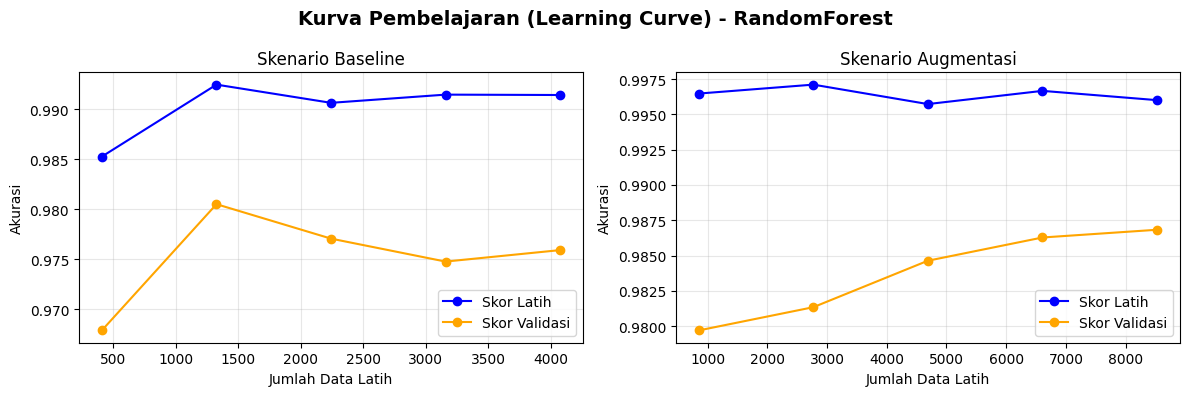

      -> Grafik Learning Curve tersimpan di: learning_curve_RandomForest_20260713_083438.png


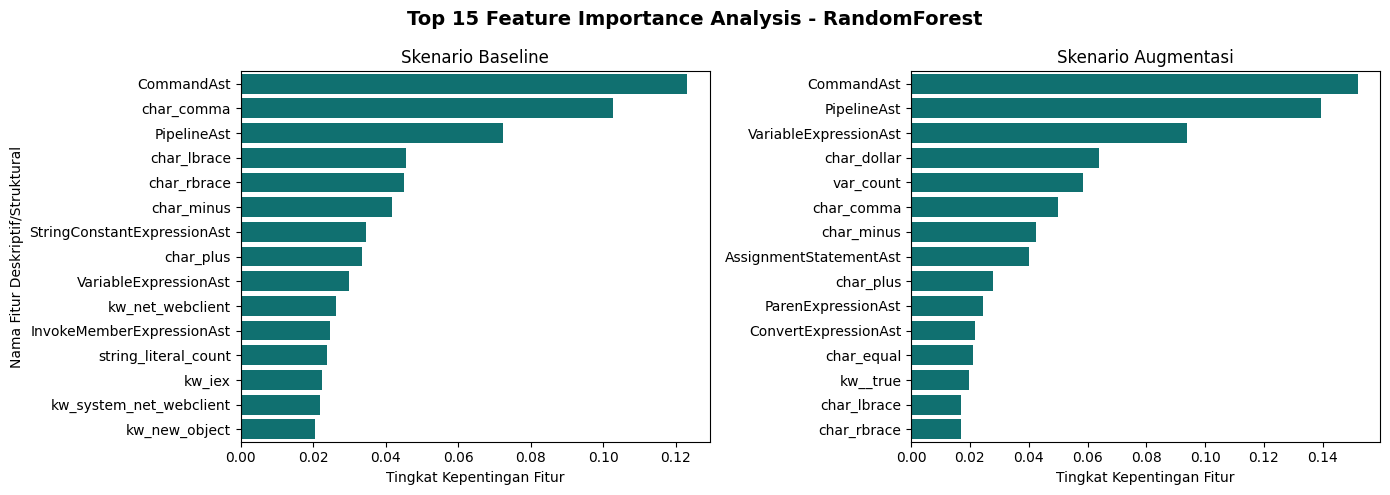

      -> Grafik Feature Importance tersimpan di: feature_importance_RandomForest_20260713_083438.png

[+] Memproses Siklus Akhir Algoritma: XGBoost...
      -> Model Baseline tersimpan di: model_XGBoost_Baseline_20260713_083438.joblib
      -> Model Augmentasi tersimpan di: model_XGBoost_Augmentasi_20260713_083438.joblib


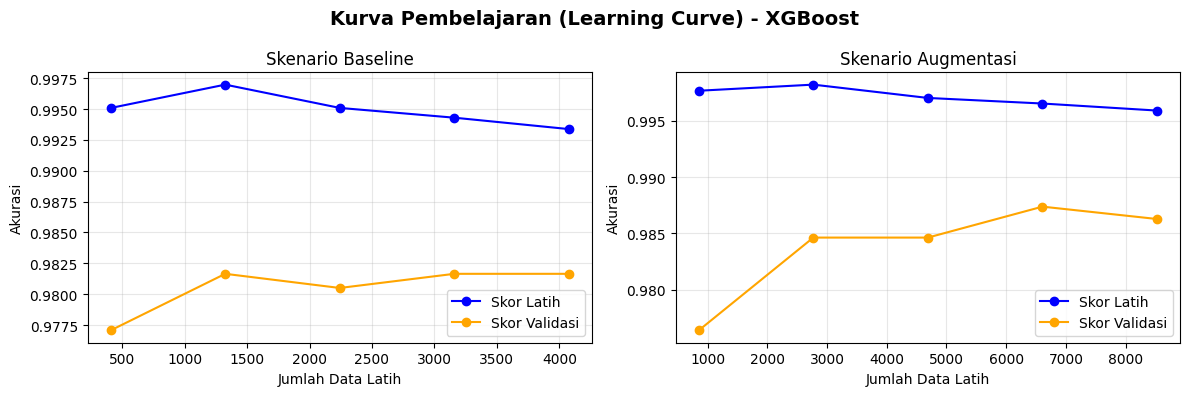

      -> Grafik Learning Curve tersimpan di: learning_curve_XGBoost_20260713_083438.png


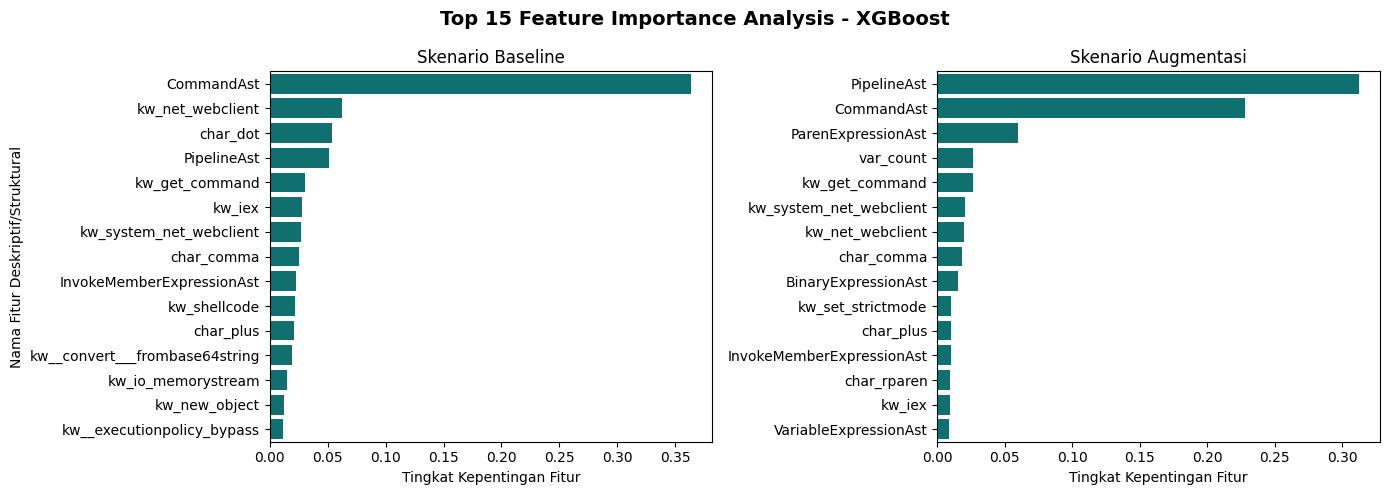

      -> Grafik Feature Importance tersimpan di: feature_importance_XGBoost_20260713_083438.png

[+] Memproses Siklus Akhir Algoritma: LightGBM...
      -> Model Baseline tersimpan di: model_LightGBM_Baseline_20260713_083438.joblib
      -> Model Augmentasi tersimpan di: model_LightGBM_Augmentasi_20260713_083438.joblib


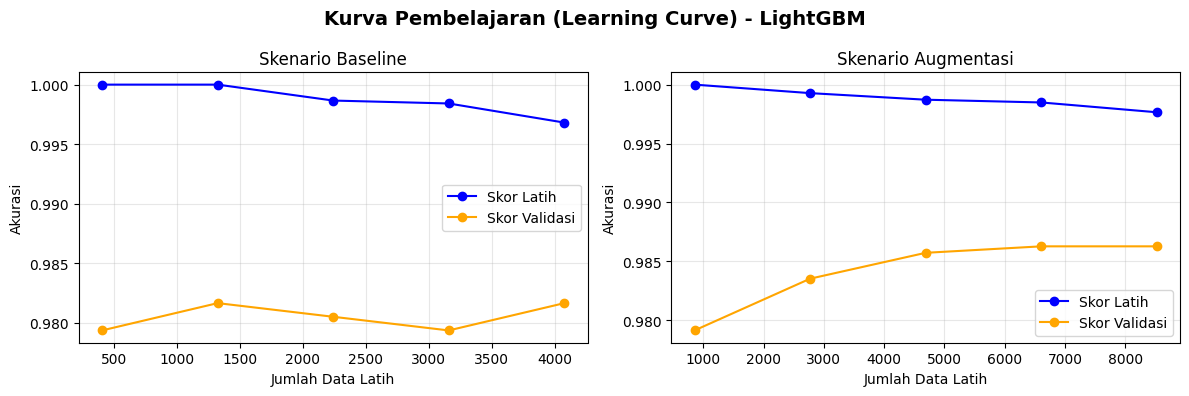

      -> Grafik Learning Curve tersimpan di: learning_curve_LightGBM_20260713_083438.png


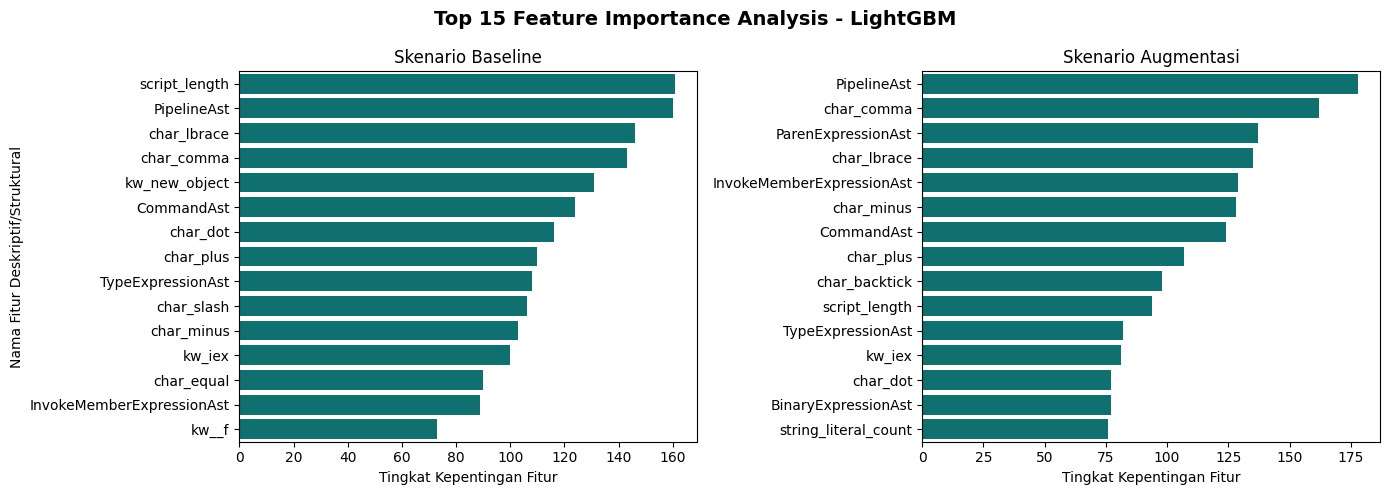

      -> Grafik Feature Importance tersimpan di: feature_importance_LightGBM_20260713_083438.png
⏹ EKSEKUSI MODELING SELESAI. Total Waktu: 0.66 Menit.


In [6]:
import time
from datetime import datetime

# =====================================================================
# EKSEKUSI PIPA UTAMA (MAIN RUN) DENGAN PENGUKUR WAKTU
# =====================================================================
print("="*80)
print(f"▶ MULAI EKSEKUSI PIPELINE MODELING: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)
waktu_mulai_modeling = time.time()

if not BASELINE_CSV.exists():
    print(f"❌ [ERROR] Berkas induk murni tidak ditemukan di: {BASELINE_CSV}")
else:
    print("[*] Memuat matriks fitur latih murni (Baseline)...")
    df_train_base = pd.read_csv(BASELINE_CSV).fillna(0)

    print("[*] Melakukan parsing komparatif 4 file teknik obfuskasi hasil sampling...")
    list_df_aug = []
    for file_name in AUGMENTATION_FILES:
        # Membaca data dari INPUT_DIR
        file_path = INPUT_DIR / file_name
        if file_path.exists():
            list_df_aug.append(pd.read_csv(file_path).fillna(0))
            print(f"    - Terbaca sukses: {file_name} (375 Sampel)")
        else:
            print(f"    [!] Peringatan: Berkas berkode {file_name} tidak ditemukan di direktori!")

    if not list_df_aug:
        print("❌ [ERROR] Pipeline dibatalkan. Berkas data augmentasi tersegregasi kosong!")
    else:
        # Penyatuan terstruktur seluruh matriks augmentasi (4 * 375 = 1.500 baris)
        df_aug_1500 = pd.concat(list_df_aug, ignore_index=True)
        
        print(f"\n📊 Kesiapan Postur Dataset Latih:")
        print(f"   -> Volume Data Latih Baseline murni : {len(df_train_base):,} Baris")
        print(f"   -> Volume Data Augmentasi Sintetis   : {len(df_aug_1500):,} Baris\n")

        # Eksekusi Tahap 1: Evaluasi Silang K-Fold Kontrol
        summary_results = run_kfold_cross_validation(df_train_base, df_aug_1500)
        _print_formatted_results(summary_results)
        
        # Simpan CSV metrik hasil K-Fold secara permanen
        _export_metrics_to_csv(summary_results, waktu_sekarang)
        
        # Eksekusi Tahap 2: Retrain Massal, Ekspor Serializer, dan Pembuatan Diagram
        fit_and_export_final_models(df_train_base, df_aug_1500)

# Kalkulasi durasi akhir
durasi_modeling = (time.time() - waktu_mulai_modeling) / 60
print("="*80)
print(f"⏹ EKSEKUSI MODELING SELESAI. Total Waktu: {durasi_modeling:.2f} Menit.")
print("="*80)